# K-Nearest Neighbors (KNN) Classification: Emissions Analysis
**Developer:** Alexandra Yu  
**Course:** CMOR 438  

---

## 1. Introduction
**K-Nearest Neighbors (KNN)** is a non-parametric, instance-based learning algorithm. Unlike the Perceptron, it doesn't learn a single line; instead, it classifies new data points based on the "majority vote" of the $k$ closest labeled points in the feature space.

### Objectives:
1. **Part 1: Toy Data**: Verify the KNN logic using simple, synthetic clusters.
2. **Part 2: Emissions Data**: Classify countries as **High** or **Low** emitters based on historical greenhouse gas (GHG) trends.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fix path to find our custom models
sys.path.append(os.path.abspath("../src"))

from my_ml_package.supervised.knn import KNearestNeighbors

## 2. Part 1: Toy Data Sanity Check
We create a small synthetic dataset where points are grouped into "A" and "B" categories. We will test if the KNN can correctly identify the category of a new, unknown point.

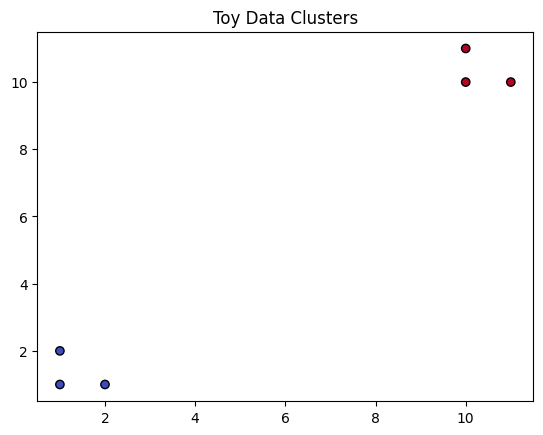

Prediction for point [1.5, 1.5]: A (Expected: A)


In [2]:
# Create synthetic data
X_toy = np.array([[1, 1], [1, 2], [2, 1], [10, 10], [10, 11], [11, 10]])
y_toy = np.array(['A', 'A', 'A', 'B', 'B', 'B'])

# Plot Toy Data
plt.scatter(X_toy[:,0], X_toy[:,1], c=(y_toy == 'B'), cmap='coolwarm', edgecolors='k')
plt.title("Toy Data Clusters")
plt.show()

# Test KNN
knn_toy = KNearestNeighbors(k_neighbors=3)
knn_toy.fit(X_toy, y_toy)

# Predict for a point right in the middle of Cluster A
sample = np.array([[1.5, 1.5]])
pred = knn_toy.predict(sample)
print(f"Prediction for point [1.5, 1.5]: {pred[0]} (Expected: A)")

## 3. Part 2: Real-World Emissions Analysis
Now we apply our KNN model to the `emissions.csv` dataset. Our goal is to predict if a country's emission status is **High** or **Low** based on the year and their per capita GHG output.

In [3]:
# Load Data
df = pd.read_csv('../data/emissions.csv').dropna()

# Preprocessing: Create a CATEGORICAL target
# Label countries above the median as 'High' and below as 'Low'
median_val = df['total_ghg'].median()
df['emission_status'] = np.where(df['total_ghg'] > median_val, 'High', 'Low')

# Prepare Features (X) and Target (y)
X = df[['year', 'ghg_per_capita']].values
y = df['emission_status'].values

print(f"Data Loaded. Median GHG: {median_val:.2f}")
df.head()

Data Loaded. Median GHG: 34.41


,country,year,iso_code,total_ghg,ghg_per_capita,emission_status
0,Afghanistan,1950,AFG,19.868742,2.555078,Low
1,Afghanistan,1951,AFG,21.069101,2.673967,Low
2,Afghanistan,1952,AFG,22.094320,2.766014,Low
3,Afghanistan,1953,AFG,23.255630,2.872235,Low
4,Afghanistan,1954,AFG,24.250988,2.954572,Low


## 4. Model Training
We use a subset of the data (`[::50]`) for training to ensure the visualization remains responsive, while still capturing the general distribution of the data.

In [4]:
# Initialize and Fit
knn_model = KNearestNeighbors(k_neighbors=5)
# Using a subset for speed
X_train = X[::50]
y_train = y[::50]
knn_model.fit(X_train, y_train)

# Make Predictions on new samples
test_sample = np.array([[2020, 12.5], [1970, 2.1]])
predictions = knn_model.predict(test_sample)

print(f"Prediction for 2020 (12.5 per capita): {predictions[0]}")
print(f"Prediction for 1970 (2.1 per capita): {predictions[1]}")

Prediction for 2020 (12.5 per capita): High
Prediction for 1970 (2.1 per capita): Low


## 5. Visualization
The plot below shows the distribution of emissions status over time. The KNN algorithm looks at the neighbors of any given point to determine its color.

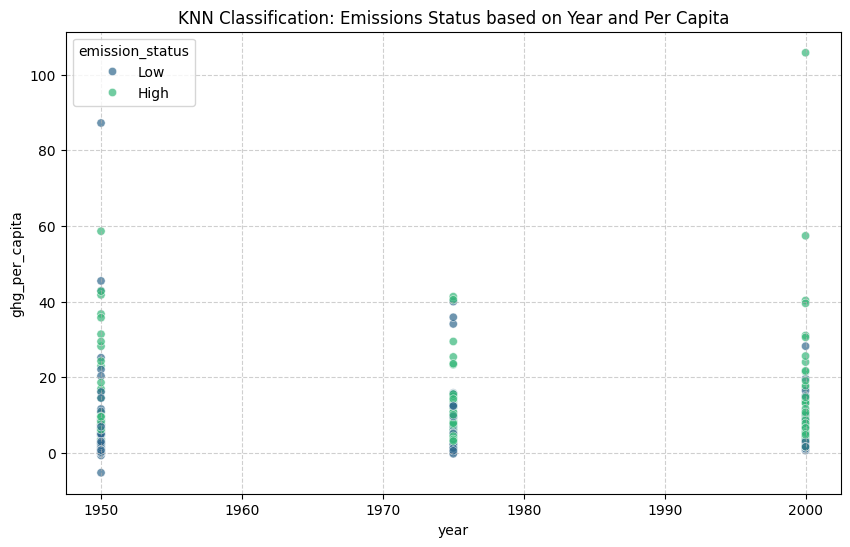

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[::50], x='year', y='ghg_per_capita', hue='emission_status', 
                palette='viridis', alpha=0.7, edgecolor='w')
plt.title("KNN Classification: Emissions Status based on Year and Per Capita")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 6. Conclusion
The KNN model effectively captures the clusters of high and low emitting countries. Unlike the linear boundary of a Perceptron, KNN can handle more complex, non-linear shapes in data, though it is more computationally expensive as the dataset grows.